# Phase 2: Figures 1 and 2

**Figure 1** — Euler-Maruyama simulation of solar GHI for Bologna, 2016–2022 (3-panel: sub-daily simulated path, daily sampled, realized GHI).

**Figure 2** — 1-day and 365-day conditional forecast densities for 2014-09-15, with 90% CI and realized GHI marker.

Both figures use parameters calibrated on the 2013 training window (2005-01-01 to 2013-12-31).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.forecastDensity import (
    clearsky_at, seasonal_mean_Y_at, R_to_Y, Y_to_R,
    conditional_moments_Y,
    mixture_pdf_R, mixture_cdf_R, mixture_quantile_R, mixture_expected_R,
)
from solarrpy.simulator import simulate_ou_mixture

## 0. Load data and calibrate (2013 window)

In [2]:
df = pd.read_csv('../data/Bologna.csv', parse_dates=['date'])
df_train = df[df['Year'] <= 2013].copy()

print('Training data: 2005-01-01 to 2013-12-31 —', len(df_train), 'rows')

cal = calibrate_window(
    df_train,
    target_col='GHI',
    clearsky_col='clearsky',
    date_col='date',
    coords={'lat': 44.5},
    train_end_year=2013,
)
print(f'θ = {cal.theta:.4f},  α = {cal.alpha:.4f},  β = {cal.beta:.4f}')
print(f'a = {cal.a}  (seasonal mean Y)')
print(f'c = {cal.c}  (continuous-time variance)')

Training data: 2005-01-01 to 2013-12-31 — 3287 rows
θ = 0.9253,  α = 0.0007,  β = 0.9230
a = [-0.07190027 -0.07330473 -0.38820932]  (seasonal mean Y)
c = [1.6192182  0.27489198 0.9470962 ]  (continuous-time variance)


## 1. Figure 1 — Euler-Maruyama simulation (2016-2022)

In [3]:
print('Running simulation 2016-01-01 → 2022-12-31 (dt=0.05, 1 path)...')
sim = simulate_ou_mixture(
    cal,
    t_start='2016-01-01',
    t_end='2022-12-31',
    dt=0.05,
    n_paths=1,
    seed=2025,
)
print('Done. Shape:', sim.shape)
print(sim[['date', 'C_t', 'R_sim_0']].head())

Running simulation 2016-01-01 → 2022-12-31 (dt=0.05, 1 path)...
Done. Shape: (2557, 5)
        date       C_t   R_sim_0
0 2016-01-01  2.235678  1.135723
1 2016-01-02  2.249688  1.623745
2 2016-01-03  2.264879  0.780131
3 2016-01-04  2.281245  0.737304
4 2016-01-05  2.298784  0.455294


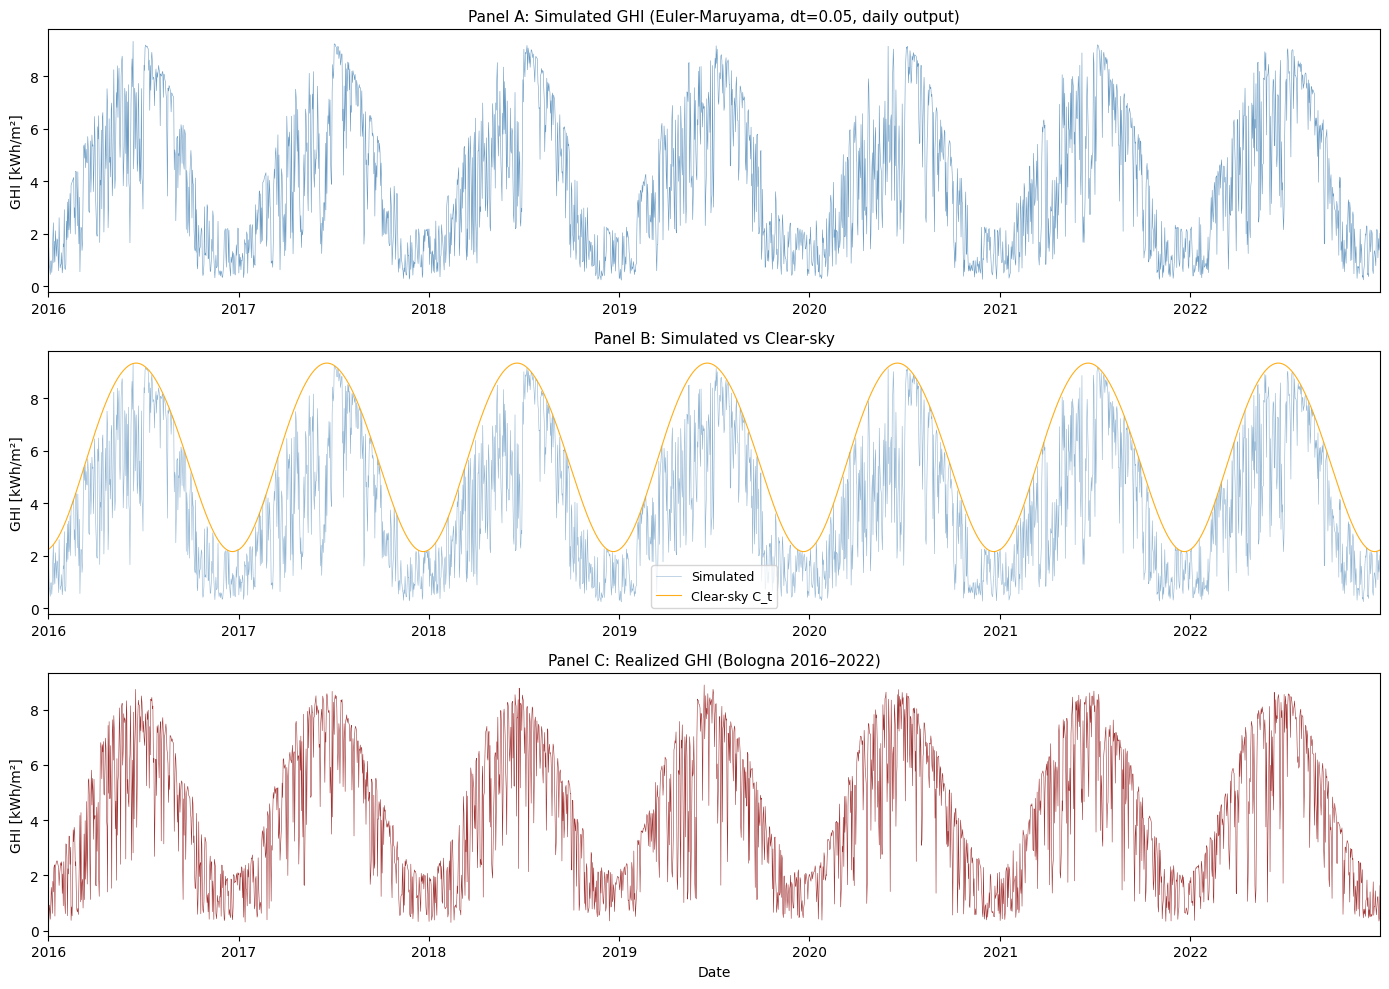

Figure 1 saved to results/Figure1_simulation.png


In [ ]:
# Realized GHI from Bologna data for 2016-2022
df_eval = df[(df['Year'] >= 2016) & (df['Year'] < 2022)].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# --- Panel A: simulated R at dt=0.05 (all sub-day steps)
# We only have daily output from simulate_ou_mixture; label accordingly
axes[0].plot(sim['date'], sim['R_sim_0'], lw=0.4, color='steelblue', alpha=0.8)
axes[0].set_title('Panel A: Simulated GHI (Euler-Maruyama, dt=0.05, daily output)', fontsize=11)
axes[0].set_ylabel('GHI [kWh/m²]')
axes[0].set_xlim(sim['date'].min(), sim['date'].max())

# --- Panel B: clear-sky overlay on simulated
axes[1].plot(sim['date'], sim['R_sim_0'], lw=0.4, color='steelblue', alpha=0.6, label='Simulated')
axes[1].plot(sim['date'], sim['C_t'], lw=0.8, color='orange', alpha=0.9, label='Clear-sky C_t')
axes[1].set_title('Panel B: Simulated vs Clear-sky', fontsize=11)
axes[1].set_ylabel('GHI [kWh/m²]')
axes[1].legend(fontsize=9)
axes[1].set_xlim(sim['date'].min(), sim['date'].max())

# --- Panel C: realized GHI (Bologna)
axes[2].plot(df_eval['date'], df_eval['GHI'], lw=0.4, color='darkred', alpha=0.8)
axes[2].set_title('Panel C: Realized GHI (Bologna 2016–2022)', fontsize=11)
axes[2].set_ylabel('GHI [kWh/m²]')
axes[2].set_xlabel('Date')
axes[2].set_xlim(df_eval['date'].min(), df_eval['date'].max())

fig.tight_layout()
plt.savefig('../results/Figure1_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved to results/Figure1_simulation.png')

## 2. Figure 2 — Conditional forecast density for 2014-09-15

In [5]:
T_NOW   = '2014-09-15'
T_1DAY  = '2014-09-16'
T_365   = '2015-09-15'

# Conditioning value: observed GHI at t_now
R_t = float(df.loc[df['date'] == T_NOW, 'GHI'].iloc[0])
print(f'Conditioning on R_t = {R_t:.4f} kWh/m² at {T_NOW}')

# Realized GHI at the two horizons
R_1day  = float(df.loc[df['date'] == T_1DAY, 'GHI'].iloc[0])
R_365   = float(df.loc[df['date'] == T_365,  'GHI'].iloc[0])
print(f'Realized at {T_1DAY}: {R_1day:.4f}  |  Realized at {T_365}: {R_365:.4f}')

Conditioning on R_t = 5.2550 kWh/m² at 2014-09-15
Realized at 2014-09-16: 4.8885  |  Realized at 2015-09-15: 2.7911


In [6]:
# Compute conditional moments
print('Computing 1-day moments...')
m1d   = conditional_moments_Y(R_t, T_NOW, T_1DAY, cal)
print('Computing 365-day moments...')
m365d = conditional_moments_Y(R_t, T_NOW, T_365, cal)

print(f'\n1-day  → mu1={m1d["mu1"]:.3f}, mu0={m1d["mu0"]:.3f}, '
      f'var1={m1d["var1"]:.3f}, var0={m1d["var0"]:.3f}, p_T={m1d["p_T"]:.3f}')
print(f'365-day → mu1={m365d["mu1"]:.3f}, mu0={m365d["mu0"]:.3f}, '
      f'var1={m365d["var1"]:.3f}, var0={m365d["var0"]:.3f}, p_T={m365d["p_T"]:.3f}')

Computing 1-day moments...
Computing 365-day moments...

1-day  → mu1=-0.736, mu0=0.635, var1=0.642, var0=0.128, p_T=0.227
365-day → mu1=-0.520, mu0=0.842, var1=6.376, var0=5.869, p_T=0.227


In [7]:
# Compute 90% CI and expected value for both horizons
print('Computing quantiles and expected values...')

q05_1d  = mixture_quantile_R(0.05, R_t, T_NOW, T_1DAY, cal)
q95_1d  = mixture_quantile_R(0.95, R_t, T_NOW, T_1DAY, cal)
E_1d    = mixture_expected_R(R_t, T_NOW, T_1DAY, cal)

q05_365 = mixture_quantile_R(0.05, R_t, T_NOW, T_365, cal)
q95_365 = mixture_quantile_R(0.95, R_t, T_NOW, T_365, cal)
E_365   = mixture_expected_R(R_t, T_NOW, T_365, cal)

print(f'1-day  90% CI: [{q05_1d:.3f}, {q95_1d:.3f}],  E[R_T]={E_1d:.3f}')
print(f'365-day 90% CI: [{q05_365:.3f}, {q95_365:.3f}],  E[R_T]={E_365:.3f}')
print(f'Realized 1-day in CI: {q05_1d <= R_1day <= q95_1d}')
print(f'Realized 365-day in CI: {q05_365 <= R_365 <= q95_365}')

Computing quantiles and expected values...
1-day  90% CI: [1.779, 5.993],  E[R_T]=4.712
365-day 90% CI: [0.631, 6.270],  E[R_T]=3.876
Realized 1-day in CI: True
Realized 365-day in CI: True


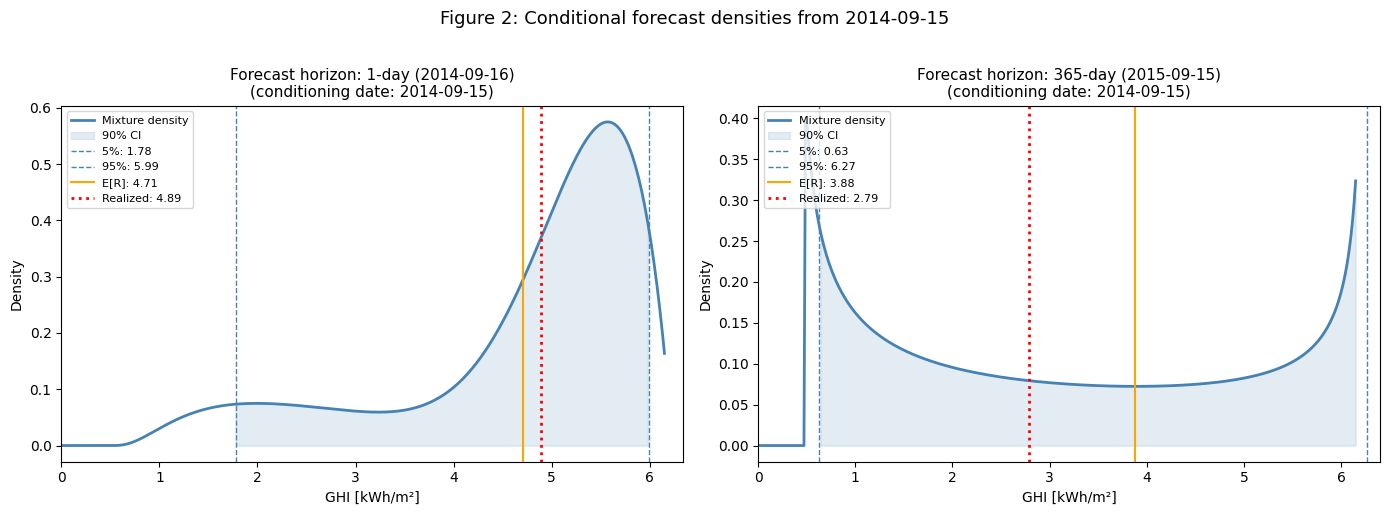

Figure 2 saved to results/Figure2_forecast_density.png


In [8]:
# GHI grid for plotting
C_T_1d  = clearsky_at(T_1DAY, cal)
C_T_365 = clearsky_at(T_365, cal)

# Use the same grid for both (cover wider range)
R_grid = np.linspace(0.01, max(C_T_1d, C_T_365) * 0.98, 400)

# Density curves
f_1d  = np.array([mixture_pdf_R(r, R_t, T_NOW, T_1DAY, cal) for r in R_grid])
f_365 = np.array([mixture_pdf_R(r, R_t, T_NOW, T_365,  cal) for r in R_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, f_vals, q5, q95, E_R, R_real, T_label, C_T in [
    (axes[0], f_1d,  q05_1d,  q95_1d,  E_1d,  R_1day, '1-day (2014-09-16)',  C_T_1d),
    (axes[1], f_365, q05_365, q95_365, E_365, R_365,  '365-day (2015-09-15)', C_T_365),
]:
    ax.plot(R_grid, f_vals, color='steelblue', lw=2, label='Mixture density')
    ax.fill_between(R_grid, f_vals,
                    where=(R_grid >= q5) & (R_grid <= q95),
                    alpha=0.15, color='steelblue', label='90% CI')
    ax.axvline(q5,    color='steelblue', ls='--', lw=1, label=f'5%: {q5:.2f}')
    ax.axvline(q95,   color='steelblue', ls='--', lw=1, label=f'95%: {q95:.2f}')
    ax.axvline(E_R,   color='orange',    ls='-',  lw=1.5, label=f'E[R]: {E_R:.2f}')
    ax.axvline(R_real, color='red',      ls=':',  lw=2,   label=f'Realized: {R_real:.2f}')
    ax.set_title(f'Forecast horizon: {T_label}\n(conditioning date: {T_NOW})', fontsize=11)
    ax.set_xlabel('GHI [kWh/m²]')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0, C_T * 1.02)

fig.suptitle('Figure 2: Conditional forecast densities from 2014-09-15', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('../results/Figure2_forecast_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved to results/Figure2_forecast_density.png')

## 3. Phase 2 gate checks

In [9]:
# Gate: 1-day 90% CI should contain the realized GHI
assert q05_1d <= R_1day <= q95_1d, f'GATE FAIL: realized {R_1day} not in [{q05_1d}, {q95_1d}]'
print('GATE PASS: 1-day 90% CI contains realized GHI at 2014-09-16')

# Sanity: unconditional density integrates to ~1 over the GHI domain
from scipy.integrate import trapezoid
integral_1d = trapezoid(f_1d, R_grid)
print(f'Density integral (1-day): {integral_1d:.4f}  (should be ≈ 1.0)')
assert 0.90 <= integral_1d <= 1.05, f'Density does not integrate to 1: {integral_1d}'
print('GATE PASS: density integrates to ≈ 1')

# Sanity: 365-day variance should be much larger than 1-day
assert m365d['var1'] > m1d['var1'] * 5, 'Expected 365-day variance >> 1-day variance'
print('GATE PASS: 365-day variance > 5× 1-day variance')

GATE PASS: 1-day 90% CI contains realized GHI at 2014-09-16
Density integral (1-day): 0.9937  (should be ≈ 1.0)
GATE PASS: density integrates to ≈ 1
GATE PASS: 365-day variance > 5× 1-day variance


In [10]:
print('\nPhase 2 complete.')
print(f'  Figure 1 → results/Figure1_simulation.png')
print(f'  Figure 2 → results/Figure2_forecast_density.png')


Phase 2 complete.
  Figure 1 → results/Figure1_simulation.png
  Figure 2 → results/Figure2_forecast_density.png
